In [1]:
from __future__ import print_function
from __future__ import unicode_literals
from __future__ import division
import functools
from itertools import tee

import six

def memoized_property(fget):
    """Decorator to create memoized properties."""
    attr_name = '_{}'.format(fget.__name__)

    @functools.wraps(fget)
    def fget_memoized(self):
        if not hasattr(self, attr_name):
            setattr(self, attr_name, fget(self))
        return getattr(self, attr_name)
    return property(fget_memoized)


def pairwise(iterable):
    """Utility function to iterate in a pairwise fashion."""
    a, b = tee(iterable)
    next(b, None)
    return six.moves.zip(a, b)

In [2]:
# -*- coding: utf-8 -*-
"""
molvs.tautomer
~~~~~~~~~~~~~~

This module contains tools for enumerating tautomers and determining a canonical tautomer.

"""

from __future__ import print_function
from __future__ import unicode_literals
from __future__ import division
import copy
import logging

from rdkit import Chem
from rdkit.Chem.rdchem import BondDir, BondStereo, BondType


log = logging.getLogger(__name__)


class TautomerTransform(object):
    """Rules to transform one tautomer to another.

    Each TautomerTransform is defined by a SMARTS pattern where the transform involves moving a hydrogen from the first
    atom in the pattern to the last atom in the pattern. By default, alternating single and double bonds along the
    pattern are swapped accordingly to account for the hydrogen movement. If necessary, the transform can instead define
    custom resulting bond orders and also resulting atom charges.
    """

    BONDMAP = {'-': BondType.SINGLE, '=': BondType.DOUBLE, '#': BondType.TRIPLE, ':': BondType.AROMATIC}
    CHARGEMAP = {'+': 1, '0': 0, '-': -1}

    def __init__(self, name, smarts, bonds=(), charges=(), radicals=()):
        """Initialize a TautomerTransform with a name, SMARTS pattern and optional bonds and charges.

        The SMARTS pattern match is applied to a Kekule form of the molecule, so use explicit single and double bonds
        rather than aromatic.

        Specify custom bonds as a string of ``-``, ``=``, ``#``, ``:`` for single, double, triple and aromatic bonds
        respectively. Specify custom charges as ``+``, ``0``, ``-`` for +1, 0 and -1 charges respectively.

        :param string name: A name for this TautomerTransform.
        :param string smarts: SMARTS pattern to match for the transform.
        :param string bonds: Optional specification for the resulting bonds.
        :param string charges: Optional specification for the resulting charges on the atoms.
        """
        self.name = name
        self.tautomer_str = smarts
        self.bonds = [self.BONDMAP[b] for b in bonds]
        self.charges = [self.CHARGEMAP[b] for b in charges]
        # TODO: Raise error (ValueError?) if bonds and charges lists are not the correct length

    @memoized_property
    def tautomer(self):
        return Chem.MolFromSmarts(self.tautomer_str)

    def __repr__(self):
        return 'TautomerTransform({!r}, {!r}, {!r}, {!r})'.format(self.name, self.tautomer_str, self.bonds, self.charges)

    def __str__(self):
        return self.name


class TautomerScore(object):
    """A substructure defined by SMARTS and its score contribution to determine the canonical tautomer."""

    def __init__(self, name, smarts, score):
        """Initialize a TautomerScore with a name, SMARTS pattern and score.

        :param name: A name for this TautomerScore.
        :param smarts: SMARTS pattern to match a substructure.
        :param score: The score to assign for this substructure.
        """
        self.name = name
        self.smarts_str = smarts
        self.score = score

    @memoized_property
    def smarts(self):
        return Chem.MolFromSmarts(self.smarts_str)

    def __repr__(self):
        return 'TautomerScore({!r}, {!r}, {!r})'.format(self.name, self.smarts_str, self.score)

    def __str__(self):
        return self.name


#: The default list of TautomerTransforms.
TAUTOMER_TRANSFORMS = (
    TautomerTransform('1,3 (thio)keto/enol f', '[CX4!H0R{0-2}]-[C;z{1-2}]=[O,S,Se,Te;X1]'),
    TautomerTransform('1,3 (thio)keto/enol r', '[O,S,Se,Te;X2!H0]-[#6;z{1-2}]=[C,cz{0-1}R{0-1}]'),
    TautomerTransform('1,5 (thio)keto/enol f', '[CX4z0,NX3;!H0]-[C]=[C][Cz1H0]=[O,S,Se,Te;X1]'),
    TautomerTransform('1,5 (thio)keto/enol r', '[O,S,Se,Te;X2!H0]-[Cz1H0]=[C]-[C]=[Cz0,N]'),
    TautomerTransform('aliphatic imine f', '[CX4R{0-2}!H0]-[Cz1]=[NX2;N!H0,$(N-a)]'),
    TautomerTransform('aliphatic imine r', '[NX3;NH2,$([NH1]-a)]-[C;z{1-2}]=[CX3]'),
    TautomerTransform('special imine f', '[Nz0!H0]-[C]=[Cz0X3R0]'),
    TautomerTransform('special imine r', '[Cz0R0X4!H0]-[c]=[nz0]'),
    TautomerTransform('1,3 aromatic heteroatom H shift f', '[#7+0!H0]-[#6R1]=[O,#7X2+0]'),
    TautomerTransform('1,3 aromatic heteroatom H shift r', '[O,#7+0;!H0]-[#6R1]=[#7+0X2]'),
    TautomerTransform('1,3 heteroatom H shift', '[#7+0,S,O,Se,Te;!H0]-[#7X2,#6,#15X3H0]=[#7+0,#16,#8,Se,Te]'),
    TautomerTransform('1,5 aromatic heteroatom H shift', '[#7+0,#16,#8;!H0]-[#6,#7]=[#6]-[#6,#7]=[#7+0,#16,#8;H0]'),
    TautomerTransform('1,5 aromatic heteroatom H shift f', '[#7+0,#16,#8,Se,Te;!H0]-[#6,nX2]=[#6,nX2]-[#6,#7X2]=[#7X2+0,S,O,Se,Te]'),
    TautomerTransform('1,5 aromatic heteroatom H shift r', '[#7+0,S,O,Se,Te;!H0]-[#6,#7X2]=[#6,nX2]-[#6,nX2]=[#7+0,#16,#8,Se,Te]'),
    TautomerTransform('1,7 aromatic heteroatom H shift f', '[#7+0,#8,#16,Se,Te;!H0]-[#6,#7X2]=[#6,#7X2]-[#6,#7X2]=[#6]-[#6,#7X2]=[#7X2+0,S,O,Se,Te,Cz0X3]'),
    TautomerTransform('1,7 aromatic heteroatom H shift r', '[#7+0,S,O,Se,Te,Cz0X4;!H0]-[#6,#7X2]=[#6]-[#6,#7X2]=[#6,#7X2]-[#6,#7X2]=[NX2,S,O,Se,Te]'),
    TautomerTransform('1,9 aromatic heteroatom H shift f', '[#7+0,O;!H0]-[#6,#7X2]=[#6,#7X2]-[#6,#7X2]=[#6,#7X2]-[#6,#7X2]=[#6,#7X2]-[#6,#7X2]=[#7+0,O]'),
    TautomerTransform('1,11 aromatic heteroatom H shift f', '[#7+0,O;!H0]-[#6,nX2]=[#6,nX2]-[#6,nX2]=[#6,nX2]-[#6,nX2]=[#6,nX2]-[#6,nX2]=[#6,nX2]-[#6,nX2]=[#7X2+0,O]'),
    TautomerTransform('furanone f', '[O,S,N;!H0]-[#6z2r5]=,:[#6X3r5;$([#6]([#6;r5])=,:[#6X3r5])]'),
    TautomerTransform('furanone r', '[#6r5!H0;$([#6]([#6r5])[#6r5])][#6z2r5]=[O,S,N]'),
    TautomerTransform('keten/ynol f', '[C!H0]=[C]=[O,S,Se,Te;X1]', bonds='#-'),
    TautomerTransform('keten/ynol r', '[O,S,Se,Te;!H0X2]-[C]#[C]', bonds='=='),
    TautomerTransform('ionic nitro/aci-nitro f', '[C!H0]-[N+;$([N][O-])]=[O]'),
    TautomerTransform('ionic nitro/aci-nitro r', '[O!H0]-[N+;$([N][O-])]=[C]'),
    TautomerTransform('oxim/nitroso f', '[O!H0]-[Nz1]=[C]'),
    TautomerTransform('oxim/nitroso r', '[C!H0]-[Nz1]=[O]'),
    TautomerTransform('oxim/nitroso via phenol f', '[O!H0]-[N]=[C]-[C]=[C]-[C]=[OH0]'),
    TautomerTransform('oxim/nitroso via phenol r', '[O!H0]-[c]=,:[c][c]=,:[c]-[N]=[OH0]'),
    TautomerTransform('cyano/iso-cyanic acid f', '[O!H0]-[C]#[N]', bonds='=='),
    TautomerTransform('cyano/iso-cyanic acid r', '[N!H0]=[C]=[O]', bonds='#-'),
    # TautomerTransform('formamidinesulfinic acid f', '[O,N;!H0]-[C]=[S,Se,Te;v6]=[O]', bonds='=--'),  # TODO: WAT!?
    # TautomerTransform('formamidinesulfinic acid r', '[O!H0]-[S,Se,Te;v4]-[C]=[O,N]', bonds='=--'),
    TautomerTransform('isocyanide f', '[C-0!H0]#[N+0]', bonds='#', charges='-+'),
    TautomerTransform('isocyanide r', '[N+!H0]#[C-]', bonds='#', charges='-+'),
    TautomerTransform('phosphonic acid f', '[OH]-[PX3H0]', bonds='='),
    TautomerTransform('phosphonic acid r', '[PX4H]=[O]', bonds='-'),
)

#: The default list of TautomerScores.
TAUTOMER_SCORES = (
    TautomerScore('benzoquinone', '[#6]1([#6]=[#6][#6]([#6]=[#6]1)=,:[N,S,O])=,:[N,S,O]', 25),
    TautomerScore('oxim', '[#6]=[N][OH]', 4),
    TautomerScore('C=O', '[#6]=,:[#8]', 2),
    TautomerScore('N=O', '[#7]=,:[#8]', 2),
    TautomerScore('P=O', '[#15]=,:[#8]', 2),
    TautomerScore('C=hetero', '[#6]=[!#1;!#6]', 1),
    TautomerScore('methyl', '[CX4H3]', 1),
    TautomerScore('guanidine terminal=N', '[#7][#6](=[NR0])[#7H0]', 1),
    TautomerScore('guanidine endocyclic=N', '[#7;R][#6;R]([N])=[#7;R]', 2),
    TautomerScore('aci-nitro', '[#6]=[N+]([O-])[OH]', -4),
)

#: The default value for the maximum number of tautomers to enumerate, a limit to prevent combinatorial explosion.
MAX_TAUTOMERS = 1000


class TautomerCanonicalizer(object):
    """

    """

    def __init__(self, transforms=TAUTOMER_TRANSFORMS, scores=TAUTOMER_SCORES, max_tautomers=MAX_TAUTOMERS):
        """

        :param transforms: A list of TautomerTransforms to use to enumerate tautomers.
        :param scores: A list of TautomerScores to use to choose the canonical tautomer.
        :param max_tautomers: The maximum number of tautomers to enumerate, a limit to prevent combinatorial explosion.
        """
        self.transforms = transforms
        self.scores = scores
        self.max_tautomers = max_tautomers

    def __call__(self, mol):
        """Calling a TautomerCanonicalizer instance like a function is the same as calling its canonicalize(mol) method."""
        return self.canonicalize(mol)

    def canonicalize(self, mol):
        """Return a canonical tautomer by enumerating and scoring all possible tautomers.

        :param mol: The input molecule.
        :type mol: rdkit.Chem.rdchem.Mol
        :return: The canonical tautomer.
        :rtype: rdkit.Chem.rdchem.Mol
        """
        # TODO: Overload the mol parameter to pass a list of pre-enumerated tautomers
        tautomers = self._enumerate_tautomers(mol)
        if len(tautomers) == 1:
            return tautomers[0]
        # Calculate score for each tautomer
        highest = None
        for t in tautomers:
            smiles = Chem.MolToSmiles(t, isomericSmiles=True)
            log.debug('Tautomer: %s', smiles)
            score = 0
            # Add aromatic ring scores
            ssr = Chem.GetSymmSSSR(t)
            for ring in ssr:
                btypes = {t.GetBondBetweenAtoms(*pair).GetBondType() for pair in pairwise(ring)}
                elements = {t.GetAtomWithIdx(idx).GetAtomicNum() for idx in ring}
                if btypes == {BondType.AROMATIC}:
                    log.debug('Score +100 (aromatic ring)')
                    score += 100
                    if elements == {6}:
                        log.debug('Score +150 (carbocyclic aromatic ring)')
                        score += 150
            # Add SMARTS scores
            for tscore in self.scores:
                for match in t.GetSubstructMatches(tscore.smarts):
                    log.debug('Score %+d (%s)', tscore.score, tscore.name)
                    score += tscore.score
            # Add (P,S,Se,Te)-H scores
            for atom in t.GetAtoms():
                if atom.GetAtomicNum() in {15, 16, 34, 52}:
                    hs = atom.GetTotalNumHs()
                    if hs:
                        log.debug('Score %+d (%s-H bonds)', -hs, atom.GetSymbol())
                        score -= hs
            # Set as highest if score higher or if score equal and smiles comes first alphabetically
            if not highest or highest['score'] < score or (highest['score'] == score and smiles < highest['smiles']):
                log.debug('New highest tautomer: %s (%s)', smiles, score)
                highest = {'smiles': smiles, 'tautomer': t, 'score': score}
        return highest['tautomer']

    @memoized_property
    def _enumerate_tautomers(self):
        return TautomerEnumerator(self.transforms, self.max_tautomers)


class TautomerEnumerator(object):
    """

    """

    def __init__(self, transforms=TAUTOMER_TRANSFORMS, max_tautomers=MAX_TAUTOMERS):
        """

        :param transforms: A list of TautomerTransforms to use to enumerate tautomers.
        :param max_tautomers: The maximum number of tautomers to enumerate (limit to prevent combinatorial explosion).
        """
        self.transforms = transforms
        self.max_tautomers = max_tautomers

    def __call__(self, mol):
        """Calling a TautomerEnumerator instance like a function is the same as calling its enumerate(mol) method."""
        return self.enumerate(mol)

    def enumerate(self, mol):
        """Enumerate all possible tautomers and return them as a list.

        :param mol: The input molecule.
        :type mol: rdkit.Chem.rdchem.Mol
        :return: A list of all possible tautomers of the molecule.
        :rtype: list of rdkit.Chem.rdchem.Mol
        """
        smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
        tautomers = {smiles: copy.deepcopy(mol)}
        # Create a kekulized form of the molecule to match the SMARTS against
        kekulized = copy.deepcopy(mol)
        Chem.Kekulize(kekulized)
        kekulized = {smiles: kekulized}
        done = set()
        while len(tautomers) < self.max_tautomers:
            for tsmiles in sorted(tautomers):
                if tsmiles in done:
                    continue
                for transform in self.transforms:
                    for match in kekulized[tsmiles].GetSubstructMatches(transform.tautomer):
                        #print('Matched rule: {} to {} for {}'.format(transform.name, tsmiles, match))
                        # log.debug('Matched rule: %s to %s for %s', transform.name, tsmiles, match)
                        # Create a copy of in the input molecule so we can modify it
                        # Use kekule form so bonds are explicitly single/double instead of aromatic
                        product = copy.deepcopy(kekulized[tsmiles])
                        # Remove a hydrogen from the first matched atom and add one to the last
                        first = product.GetAtomWithIdx(match[0])
                        last = product.GetAtomWithIdx(match[-1])
                        # log.debug('%s: H%s -> H%s' % (first.GetSymbol(), first.GetTotalNumHs(), first.GetTotalNumHs() - 1))
                        # log.debug('%s: H%s -> H%s' % (last.GetSymbol(), last.GetTotalNumHs(), last.GetTotalNumHs() + 1))
                        first.SetNumExplicitHs(max(0, first.GetTotalNumHs() - 1))
                        last.SetNumExplicitHs(last.GetTotalNumHs() + 1)
                        # Remove any implicit hydrogens from the first and last atoms now we have set the count explicitly
                        first.SetNoImplicit(True)
                        last.SetNoImplicit(True)
                        # Adjust bond orders
                        for bi, pair in enumerate(pairwise(match)):
                            if transform.bonds:
                                # Set the resulting bond types as manually specified in the transform
                                # log.debug('%s-%s: %s -> %s' % (product.GetAtomWithIdx(pair[0]).GetSymbol(), product.GetAtomWithIdx(pair[1]).GetSymbol(), product.GetBondBetweenAtoms(*pair).GetBondType(), transform.bonds[bi]))
                                product.GetBondBetweenAtoms(*pair).SetBondType(transform.bonds[bi])
                            else:
                                # If no manually specified bond types, just swap single and double bonds
                                current_bond_type = product.GetBondBetweenAtoms(*pair).GetBondType()
                                product.GetBondBetweenAtoms(*pair).SetBondType(BondType.DOUBLE if current_bond_type == BondType.SINGLE else BondType.SINGLE)
                                # log.debug('%s-%s: %s -> %s' % (product.GetAtomWithIdx(pair[0]).GetSymbol(), product.GetAtomWithIdx(pair[1]).GetSymbol(), current_bond_type, product.GetBondBetweenAtoms(*pair).GetBondType()))
                        # Adjust charges
                        if transform.charges:
                            for ci, idx in enumerate(match):
                                atom = product.GetAtomWithIdx(idx)
                                # log.debug('%s: C%s -> C%s' % (atom.GetSymbol(), atom.GetFormalCharge(), atom.GetFormalCharge() + transform.charges[ci]))
                                atom.SetFormalCharge(atom.GetFormalCharge() + transform.charges[ci])
                        try:
                            Chem.SanitizeMol(product)
                            smiles = Chem.MolToSmiles(product, isomericSmiles=True)
                            if smiles not in tautomers:
                                print('Applied rule: {} to {}, form {}'.format(transform.name, tsmiles, smiles))
                            log.debug('Applied rule: %s to %s', transform.name, tsmiles)
                            if smiles not in tautomers:
                                log.debug('New tautomer produced: %s' % smiles)
                                print('New tautomer produced: %s' % smiles)
                                print('-'*20)
                                kekulized_product = copy.deepcopy(product)
                                Chem.Kekulize(kekulized_product)
                                tautomers[smiles] = product
                                kekulized[smiles] = kekulized_product
                            else:
                                log.debug('Previous tautomer produced again: %s' % smiles)
                        except ValueError:
                            log.debug('ValueError Applying rule: %s', transform.name)
                done.add(tsmiles)
            if len(tautomers) == len(done):
                break
        else:
            log.warning('Tautomer enumeration stopped at maximum %s', self.max_tautomers)
        # Clean up stereochemistry
        for tautomer in tautomers.values():
            Chem.AssignStereochemistry(tautomer, force=True, cleanIt=True)
            for bond in tautomer.GetBonds():
                if bond.GetBondType() == BondType.DOUBLE and bond.GetStereo() > BondStereo.STEREOANY:
                    begin = bond.GetBeginAtomIdx()
                    end = bond.GetEndAtomIdx()
                    for othertautomer in tautomers.values():
                        if not othertautomer.GetBondBetweenAtoms(begin, end).GetBondType() == BondType.DOUBLE:
                            neighbours = tautomer.GetAtomWithIdx(begin).GetBonds() + tautomer.GetAtomWithIdx(end).GetBonds()
                            for otherbond in neighbours:
                                if otherbond.GetBondDir() in {BondDir.ENDUPRIGHT, BondDir.ENDDOWNRIGHT}:
                                    otherbond.SetBondDir(BondDir.NONE)
                            Chem.AssignStereochemistry(tautomer, force=True, cleanIt=True)
                            log.debug('Removed stereochemistry from unfixed double bond')
                            break
        return list(tautomers.values())

In [ ]:
mol = Chem.MolFromSmiles('C/C(C)=C\Cc1c(O)ccc(C2Oc3c(C/C=C(C)\C)c(O)ccc3C(C2O)=O)c1')  # Example usage, remove this line in production code
mol.GetSubstructMatches(Chem.MolFromSmarts('[OH]-c1ccccc1'))


((7, 6, 5, 29, 10, 9, 8), (21, 20, 14, 13, 24, 23, 22))

In [21]:
A = {(19, 18, 17, 15, 14, 6, 5), (11, 10, 7, 6, 14, 13, 12)}
B = {(9, 8, 7, 6, 5, 3, 2), (4, 3, 2, 8, 7, 6, 5)}
A.issuperset(B)

False

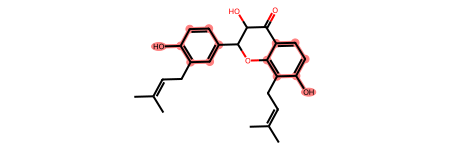

In [7]:
mol

In [ ]:
te = TautomerEnumerator()
mol = Chem.MolFromSmiles('C/C(C)=C\Cc1c(O)ccc(C2Oc3c(C/C=C(C)\C)c(O)ccc3C(C2O)=O)c1')  # Example usage, remove this line in production code
taus = te.enumerate(mol)  # Example usage, remove this line in production 


Applied rule: 1,3 (thio)keto/enol f to CC(C)=CCc1cc(C2Oc3c(ccc(O)c3CC=C(C)C)C(=O)C2O)ccc1O, form CC(C)=CCc1cc(C2Oc3c(ccc(O)c3CC=C(C)C)C(O)=C2O)ccc1O
New tautomer produced: CC(C)=CCc1cc(C2Oc3c(ccc(O)c3CC=C(C)C)C(O)=C2O)ccc1O
--------------------
Applied rule: 1,3 (thio)keto/enol r to CC(C)=CCc1cc(C2Oc3c(ccc(O)c3CC=C(C)C)C(=O)C2O)ccc1O, form CC(C)=CCc1c(O)ccc2c1OC(C1=CC(CC=C(C)C)C(=O)C=C1)C(O)C2=O
New tautomer produced: CC(C)=CCc1c(O)ccc2c1OC(C1=CC(CC=C(C)C)C(=O)C=C1)C(O)C2=O
--------------------
Applied rule: 1,3 (thio)keto/enol r to CC(C)=CCc1cc(C2Oc3c(ccc(O)c3CC=C(C)C)C(=O)C2O)ccc1O, form CC(C)=CCC1=C2OC(c3ccc(O)c(CC=C(C)C)c3)C(O)C(=O)C2=CCC1=O
New tautomer produced: CC(C)=CCC1=C2OC(c3ccc(O)c(CC=C(C)C)c3)C(O)C(=O)C2=CCC1=O
--------------------
Applied rule: 1,7 aromatic heteroatom H shift f to CC(C)=CCc1cc(C2Oc3c(ccc(O)c3CC=C(C)C)C(=O)C2O)ccc1O, form CC(C)=CCC1=C2OC(c3ccc(O)c(CC=C(C)C)c3)C(O)C(O)=C2C=CC1=O
New tautomer produced: CC(C)=CCC1=C2OC(c3ccc(O)c(CC=C(C)C)c3)C(O)C(O)=C2C=CC1=O

Tautomer enumeration stopped at maximum 1000


Applied rule: 1,3 (thio)keto/enol r to CC(C)=CCC1=CC(=C2OC3=C(CC=C(C)C)C(=O)C=CC3C(O)=C2O)CC=C1O, form CC(C)=CCC1=CC(=C2OC3=C(CC=C(C)C)C(=O)C=CC3C(O)C2=O)CC=C1O
New tautomer produced: CC(C)=CCC1=CC(=C2OC3=C(CC=C(C)C)C(=O)C=CC3C(O)C2=O)CC=C1O
--------------------
Applied rule: 1,3 (thio)keto/enol r to CC(C)=CCC1=CC(=C2OC3=C(CC=C(C)C)C(=O)C=CC3C(O)=C2O)CC=C1O, form CC(C)=CCC1=CC(=C2OC3=C(CC=C(C)C)C(=O)C=CC3C(=O)C2O)CC=C1O
New tautomer produced: CC(C)=CCC1=CC(=C2OC3=C(CC=C(C)C)C(=O)C=CC3C(=O)C2O)CC=C1O
--------------------
Applied rule: 1,5 (thio)keto/enol f to CC(C)=CCC1=CC(=C2OC3=C(CC=C(C)C)C(=O)C=CC3C(O)=C2O)CC=C1O, form CC(C)=CCC1=CC(=C2Oc3c(ccc(O)c3CC=C(C)C)C(O)=C2O)CC=C1O
New tautomer produced: CC(C)=CCC1=CC(=C2Oc3c(ccc(O)c3CC=C(C)C)C(O)=C2O)CC=C1O
--------------------
Applied rule: 1,5 (thio)keto/enol r to CC(C)=CCC1=CC(=C2OC3=C(CC=C(C)C)C(=O)C=CC3C(O)=C2O)CC=C1O, form CC(C)=CCC1=CC(C2=C(O)C(=O)C3C=CC(=O)C(CC=C(C)C)=C3O2)CC=C1O
New tautomer produced: CC(C)=CCC1=CC(C2=C(O)C(=O)C3C=C

In [14]:
for tau in taus:
    if tau.GetSubstructMatches(Chem.MolFromSmarts('[OH]-c1ccccc1')):
        print(f"{Chem.MolToSmiles(tau)}, {tau.GetSubstructMatches(Chem.MolFromSmarts('[OH]-c1ccccc1'))}")


CC(C)=CCc1cc(C2Oc3c(ccc(O)c3CC=C(C)C)C(=O)C2O)ccc1O, ((7, 6, 5, 29, 10, 9, 8), (21, 20, 14, 13, 24, 23, 22))
CC(C)=CCc1cc(C2Oc3c(ccc(O)c3CC=C(C)C)C(O)=C2O)ccc1O, ((7, 6, 5, 29, 10, 9, 8), (21, 20, 14, 13, 24, 23, 22))
CC(C)=CCc1c(O)ccc2c1OC(C1=CC(CC=C(C)C)C(=O)C=C1)C(O)C2=O, ((21, 20, 14, 13, 24, 23, 22),)
CC(C)=CCC1=C2OC(c3ccc(O)c(CC=C(C)C)c3)C(O)C(=O)C2=CCC1=O, ((7, 6, 5, 29, 10, 9, 8),)
CC(C)=CCC1=C2OC(c3ccc(O)c(CC=C(C)C)c3)C(O)C(O)=C2C=CC1=O, ((7, 6, 5, 29, 10, 9, 8),)
CC(C)=CCC1=C2OC(c3ccc(O)c(CC=C(C)C)c3)C(O)=C(O)C2=CCC1=O, ((7, 6, 5, 29, 10, 9, 8),)
CC(C)=CCC1=C2OC(c3ccc(O)c(CC=C(C)C)c3)C(O)C(=O)C2C=CC1=O, ((7, 6, 5, 29, 10, 9, 8),)
CC(C)=CCc1cc(C2OC3=C(C=CC(=O)C3CC=C(C)C)C(=O)C2O)ccc1O, ((7, 6, 5, 29, 10, 9, 8),)
CC(C)=CCc1c(O)ccc2c1OC(C1=CC(CC=C(C)C)C(=O)C=C1)C(O)=C2O, ((21, 20, 14, 13, 24, 23, 22),)
CC(C)=CCc1cc(C2Oc3c(ccc(O)c3CC=C(C)C)C(O)C2=O)ccc1O, ((7, 6, 5, 29, 10, 9, 8), (21, 20, 14, 13, 24, 23, 22))
CC(C)=CCC1=C2OC(c3ccc(O)c(CC=C(C)C)c3)C(=O)C(O)C2=CCC1=O, ((7, 6, 5, 2

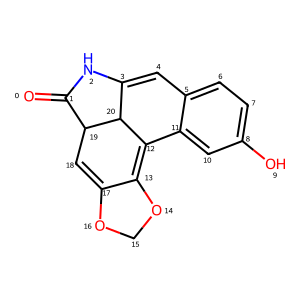

In [48]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole

IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 300,300
mol = Chem.MolFromSmiles('O=C1NC2=Cc3ccc(O)cc3C3=C4OCOC4=CC1C23')
mol.GetSubstructMatch(Chem.MolFromSmarts('[C;$([CX4H2;!$(C-[!#6])!$(C-C=[!#6])!$(C-C=C-C=[!#6])]-[CX4;!$(C-[!#6])]),$([CX4H2;!$(C-[!#6])]-[CX4;!$(C-[!#6])!$(C-C=[!#6])!$(C-C=C-C=[!#6])])]'))
mol

In [49]:
for bond in mol.GetBonds():
    if bond.GetIsConjugated():
        print(f"Bond {bond.GetBeginAtomIdx()}-{bond.GetEndAtomIdx()} is conjugated.")
    else:
        print(f"Bond {bond.GetBeginAtomIdx()}-{bond.GetEndAtomIdx()} is not conjugated.")

Bond 0-1 is conjugated.
Bond 1-2 is conjugated.
Bond 2-3 is conjugated.
Bond 3-4 is conjugated.
Bond 4-5 is conjugated.
Bond 5-6 is conjugated.
Bond 6-7 is conjugated.
Bond 7-8 is conjugated.
Bond 8-9 is conjugated.
Bond 8-10 is conjugated.
Bond 10-11 is conjugated.
Bond 11-12 is conjugated.
Bond 12-13 is conjugated.
Bond 13-14 is conjugated.
Bond 14-15 is not conjugated.
Bond 15-16 is not conjugated.
Bond 16-17 is conjugated.
Bond 17-18 is conjugated.
Bond 18-19 is not conjugated.
Bond 19-20 is not conjugated.
Bond 19-1 is not conjugated.
Bond 20-3 is not conjugated.
Bond 11-5 is conjugated.
Bond 20-12 is not conjugated.
Bond 17-13 is conjugated.


In [53]:
def has_conjugation_path(mol, start, end):
    visited = set()
    stack = [start]
    while stack:
        idx = stack.pop()
        if idx == end:
            return True
        atom = mol.GetAtomWithIdx(idx)
        for bond in atom.GetBonds():
            j = bond.GetOtherAtomIdx(idx)
            if j in visited:
                continue
            if not bond.GetIsConjugated():
                continue
            visited.add(j)
            stack.append(j)
    print(visited)
    return False

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18}
False


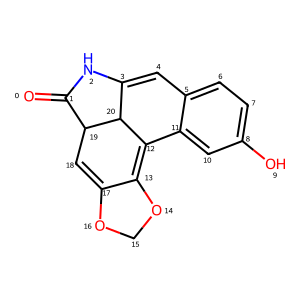

In [54]:
print(has_conjugation_path(mol, 4, 19))
mol

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16, 17, 18, 20}
False


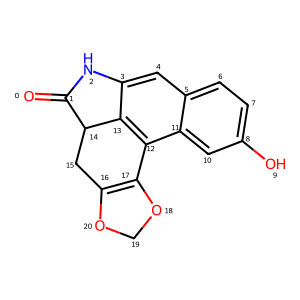

In [57]:
mol_out = Chem.MolFromSmiles('O=C1Nc2cc3ccc(O)cc3c3c2C1CC1=C3OCO1')
print(has_conjugation_path(mol_out, 4, 14))
mol_out

In [58]:
from rdkit import Chem

def get_conjugated_segments(mol):
    visited = set()
    segments = []
    for bond in mol.GetBonds():
        if not bond.GetIsConjugated():
            continue
        if bond.GetIdx() in visited:
            continue
        # BFS for this conjugated block
        seg_atoms = set()
        seg_bonds = set()
        stack = [bond]
        while stack:
            b = stack.pop()
            if b.GetIdx() in visited:
                continue
            visited.add(b.GetIdx())
            seg_bonds.add(b.GetIdx())
            seg_atoms.add(b.GetBeginAtomIdx())
            seg_atoms.add(b.GetEndAtomIdx())
            for a_idx in (b.GetBeginAtomIdx(), b.GetEndAtomIdx()):
                atom = mol.GetAtomWithIdx(a_idx)
                for nb in atom.GetBonds():
                    if nb.GetIsConjugated() and nb.GetIdx() not in visited:
                        stack.append(nb)
        segments.append((seg_atoms, seg_bonds))
    return segments

def is_pure_carbon_segment(mol, seg_atoms):
    return all(mol.GetAtomWithIdx(idx).GetAtomicNum() == 6 for idx in seg_atoms)

def pure_carbon_conjugation_violation(orig, tau):
    orig_segments = get_conjugated_segments(orig)
    for seg_atoms, seg_bonds in orig_segments:
        if not is_pure_carbon_segment(orig, seg_atoms):
            continue  # skip heteroatom-containing segments
        for bidx in seg_bonds:
            bond_orig = orig.GetBondWithIdx(bidx)
            bond_tau = tau.GetBondWithIdx(bidx)
            if bond_orig.GetBondType() != bond_tau.GetBondType():
                return True
    return False


[({0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18}, {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16, 17, 22, 24})]


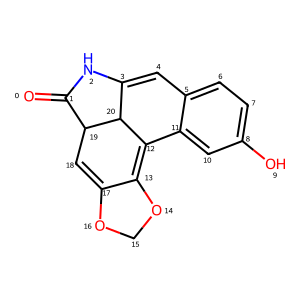

In [66]:
from rdkit.Chem.MolStandardize import rdMolStandardize

TAUTOMER_PARAMS = rdMolStandardize.CleanupParameters()
TAUTOMER_PARAMS.tautomerRemoveSp3Stereo = False
TAUTOMER_PARAMS.tautomerRemoveBondStereo = False
TAUTOMER_PARAMS.tautomerRemoveIsotopicHs = False
TAUTOMER_PARAMS.maxTransforms = 1000
TAUTOMER_PARAMS.maxTautomers = 1000
original_mol = Chem.MolFromSmiles('O=C1NC2=Cc3ccc(O)cc3C3=C4OCOC4=CC1C23')
TE = rdMolStandardize.TautomerEnumerator(TAUTOMER_PARAMS) 
print(get_conjugated_segments(original_mol))
original_mol


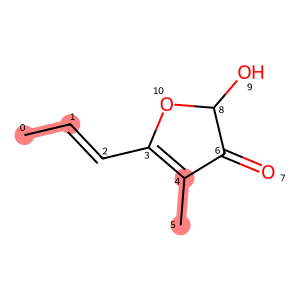

In [3]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole

IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 300,300
mol = Chem.MolFromSmiles('CC=CC1=C(C)C(=O)C(O)O1')
ethylene = Chem.MolFromSmarts('[CH3]-[CX3;!$(C-[!#6&!H0])]')
mol.GetSubstructMatches(ethylene)
mol
